## **Name:** Rohan Khadye

## **Roll no.:** 23102C0065

## **CMPN C**

# Statistical Analysis of Physical Characteristics of Palmer Penguins

## R Programming Lab – Problem Statement 6

This notebook performs the complete analysis requested in the laboratory problem statement using **R programming only**.

It covers:
- Dataset download and preprocessing
- Descriptive statistics
- Histogram, boxplots and density plots
- Shapiro-Wilk normality tests and Q-Q plots
- Independent two-sample Welch t-test
- 95% confidence interval
- Cohen's d
- One-way ANOVA
- Levene's test
- Tukey HSD
- Kruskal-Wallis test
- Two-way ANOVA with interaction
- ANOVA diagnostics
- Flipper-length analysis
- Final statistical conclusions

**Important:** This version deliberately avoids `car`, `rstatix`, `effectsize`, `tidyverse`, `knitr`, and `kableExtra`, so the notebook does not get stuck installing large dependency trees. All required calculations are implemented using **base R**.


## 1. R Environment Setup

No third-party R packages are required for the statistical calculations in this notebook. This makes the notebook faster and avoids package-installation errors in Google Colab.


In [ ]:
# ============================================
# R ENVIRONMENT SETUP
# ============================================

options(stringsAsFactors = FALSE)
set.seed(123)

cat("R version:", R.version.string, "\n")
cat("R environment initialized successfully.\n")


R version: R version 4.6.1 (2026-06-24) 
R environment initialized successfully.


## 2. Download the Palmer Penguins Dataset

The dataset is downloaded automatically as a CSV file. No manual data entry is required.

A public GitHub copy of the Palmer Penguins CSV is used so that the notebook can run without installing the `palmerpenguins` package.


In [ ]:
# ============================================
# DOWNLOAD DATASET
# ============================================

dataset_url <- "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
dataset_file <- file.path(tempdir(), "penguins.csv")

download_result <- tryCatch(
  {
    download.file(dataset_url, dataset_file, mode = "wb", quiet = TRUE)
    TRUE
  },
  error = function(e) {
    cat("Primary download failed. Trying fallback URL...\n")
    FALSE
  }
)

if (!download_result) {
  fallback_url <- "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
  download.file(fallback_url, dataset_file, mode = "wb", quiet = TRUE)
}

penguins <- read.csv(dataset_file, stringsAsFactors = FALSE)

cat("Dataset downloaded and loaded successfully.\n")
cat("Rows:", nrow(penguins), "\n")
cat("Columns:", ncol(penguins), "\n")


Dataset downloaded and loaded successfully.
Rows: 344 
Columns: 8 


## 3. Inspect the Dataset

In [ ]:
# ============================================
# DATASET INSPECTION
# ============================================

cat("First 10 rows:\n")
print(head(penguins, 10))

cat("\nLast 10 rows:\n")
print(tail(penguins, 10))

cat("\nDimensions:\n")
print(dim(penguins))

cat("\nColumn names:\n")
print(names(penguins))

cat("\nStructure:\n")
str(penguins)

cat("\nSummary:\n")
print(summary(penguins))


First 10 rows:
   species    island bill_length_mm bill_depth_mm flipper_length_mm body_mass_g
1   Adelie Torgersen           39.1          18.7               181        3750
2   Adelie Torgersen           39.5          17.4               186        3800
3   Adelie Torgersen           40.3          18.0               195        3250
4   Adelie Torgersen             NA            NA                NA          NA
5   Adelie Torgersen           36.7          19.3               193        3450
6   Adelie Torgersen           39.3          20.6               190        3650
7   Adelie Torgersen           38.9          17.8               181        3625
8   Adelie Torgersen           39.2          19.6               195        4675
9   Adelie Torgersen           34.1          18.1               193        3475
10  Adelie Torgersen           42.0          20.2               190        4250
      sex year
1    male 2007
2  female 2007
3  female 2007
4    <NA> 2007
5  female 2007
6    male 2007


## 4. Missing Values and Data Preprocessing

In [ ]:
# ============================================
# DATA PREPROCESSING
# ============================================

# Convert categorical variables to factors
penguins$species <- factor(penguins$species)
penguins$island  <- factor(penguins$island)
penguins$sex     <- factor(penguins$sex)

cat("Missing values by variable:\n")
missing_table <- data.frame(
  Variable = names(penguins),
  Missing_Values = colSums(is.na(penguins)),
  row.names = NULL
)
print(missing_table)

cat("\nDuplicate rows:", sum(duplicated(penguins)), "\n")

cat("\nSpecies levels:\n")
print(levels(penguins$species))

cat("\nSex levels:\n")
print(levels(penguins$sex))

# Analysis-specific complete datasets
body_mass_data <- penguins[
  !is.na(penguins$body_mass_g) & !is.na(penguins$species),
]

body_mass_sex_data <- penguins[
  !is.na(penguins$body_mass_g) & !is.na(penguins$sex),
]

two_way_data <- penguins[
  !is.na(penguins$body_mass_g) &
  !is.na(penguins$species) &
  !is.na(penguins$sex),
]

flipper_data <- penguins[
  !is.na(penguins$flipper_length_mm) &
  !is.na(penguins$species),
]

cat("\nSample sizes:\n")
cat("Body mass + species:", nrow(body_mass_data), "\n")
cat("Body mass + sex:", nrow(body_mass_sex_data), "\n")
cat("Two-way ANOVA:", nrow(two_way_data), "\n")
cat("Flipper length + species:", nrow(flipper_data), "\n")


Missing values by variable:
           Variable Missing_Values
1           species              0
2            island              0
3    bill_length_mm              2
4     bill_depth_mm              2
5 flipper_length_mm              2
6       body_mass_g              2
7               sex             11
8              year              0

Duplicate rows: 0 

Species levels:
[1] "Adelie"    "Chinstrap" "Gentoo"   

Sex levels:
[1] "female" "male"  

Sample sizes:
Body mass + species: 342 
Body mass + sex: 333 
Two-way ANOVA: 333 
Flipper length + species: 342 


## 5. Descriptive Statistics – Body Mass

The following function calculates all measures requested in the problem statement:
mean, median, minimum, maximum, variance, standard deviation, Q1, Q3, IQR, skewness and kurtosis.

Kurtosis is reported as **Pearson kurtosis**, where a normal distribution has kurtosis approximately equal to 3.


In [ ]:
# ============================================
# DESCRIPTIVE STATISTICS FUNCTION
# ============================================

skewness_base <- function(x) {
  x <- x[is.finite(x)]
  n <- length(x)
  m <- mean(x)
  s <- sd(x)
  if (n < 3 || s == 0) return(NA_real_)
  sum((x - m)^3) / n / (sum((x - m)^2) / n)^(3/2)
}

kurtosis_base <- function(x) {
  x <- x[is.finite(x)]
  n <- length(x)
  m <- mean(x)
  v <- sum((x - m)^2) / n
  if (n < 4 || v == 0) return(NA_real_)
  sum((x - m)^4) / n / v^2
}

descriptive_stats <- function(x) {
  x <- x[is.finite(x)]
  q <- quantile(x, c(0.25, 0.75), names = FALSE)

  data.frame(
    N = length(x),
    Mean = mean(x),
    Median = median(x),
    Minimum = min(x),
    Maximum = max(x),
    Variance = var(x),
    SD = sd(x),
    Q1 = q[1],
    Q3 = q[2],
    IQR = IQR(x),
    Skewness = skewness_base(x),
    Kurtosis = kurtosis_base(x),
    row.names = NULL
  )
}

overall_stats <- descriptive_stats(body_mass_data$body_mass_g)

cat("Overall body-mass descriptive statistics:\n")
print(round(overall_stats, 2))


Overall body-mass descriptive statistics:
    N    Mean Median Minimum Maximum Variance     SD   Q1   Q3  IQR Skewness
1 342 4201.75   4050    2700    6300 643131.1 801.95 3550 4750 1200     0.47
  Kurtosis
1     2.27


## 6. Species-wise Descriptive Statistics

In [ ]:
# ============================================
# SPECIES-WISE DESCRIPTIVE STATISTICS
# ============================================

species_levels <- levels(droplevels(body_mass_data$species))

species_stats <- do.call(
  rbind,
  lapply(species_levels, function(sp) {

    result <- descriptive_stats(
      body_mass_data$body_mass_g[
        body_mass_data$species == sp
      ]
    )

    result$Species <- sp
    result
  })
)

# Put Species as the first column
species_stats <- species_stats[, c(
  "Species",
  "N",
  "Mean",
  "Median",
  "Minimum",
  "Maximum",
  "Variance",
  "SD",
  "Q1",
  "Q3",
  "IQR",
  "Skewness",
  "Kurtosis"
)]

# Reset row names
rownames(species_stats) <- NULL

cat("Species-wise body-mass descriptive statistics:\n")

# Round ONLY numeric columns
species_stats_rounded <- species_stats

numeric_columns <- sapply(
  species_stats_rounded,
  is.numeric
)

species_stats_rounded[numeric_columns] <- lapply(
  species_stats_rounded[numeric_columns],
  round,
  digits = 2
)

print(species_stats_rounded)

Species-wise body-mass descriptive statistics:
    Species   N    Mean Median Minimum Maximum Variance     SD     Q1   Q3
1    Adelie 151 3700.66   3700    2850    4775 210282.9 458.57 3350.0 4000
2 Chinstrap  68 3733.09   3700    2700    4800 147713.5 384.34 3487.5 3950
3    Gentoo 123 5076.02   5000    3950    6300 254133.2 504.12 4700.0 5500
    IQR Skewness Kurtosis
1 650.0     0.28     2.41
2 462.5     0.24     3.46
3 800.0     0.07     2.26


## 7. Descriptive Visualizations

### 7.1 Histogram of Body Mass


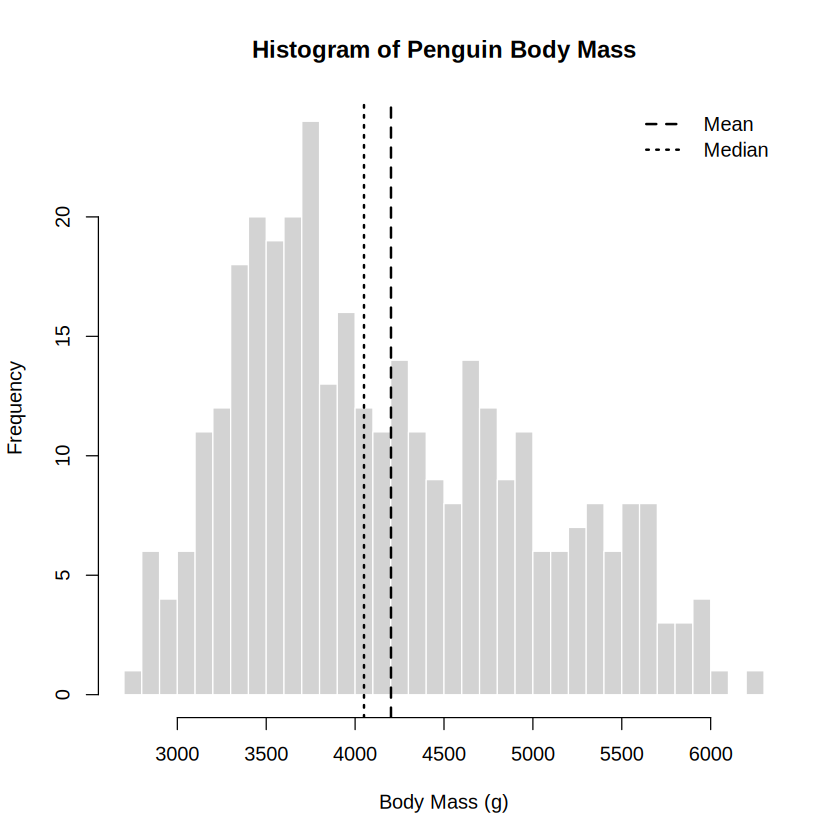

In [ ]:
# ============================================
# HISTOGRAM OF BODY MASS
# ============================================

hist(
  body_mass_data$body_mass_g,
  breaks = 30,
  main = "Histogram of Penguin Body Mass",
  xlab = "Body Mass (g)",
  ylab = "Frequency",
  col = "lightgray",
  border = "white"
)

abline(
  v = mean(body_mass_data$body_mass_g),
  lty = 2,
  lwd = 2
)

abline(
  v = median(body_mass_data$body_mass_g),
  lty = 3,
  lwd = 2
)

legend(
  "topright",
  legend = c("Mean", "Median"),
  lty = c(2, 3),
  lwd = 2,
  bty = "n"
)


### 7.2 Species-wise Boxplot

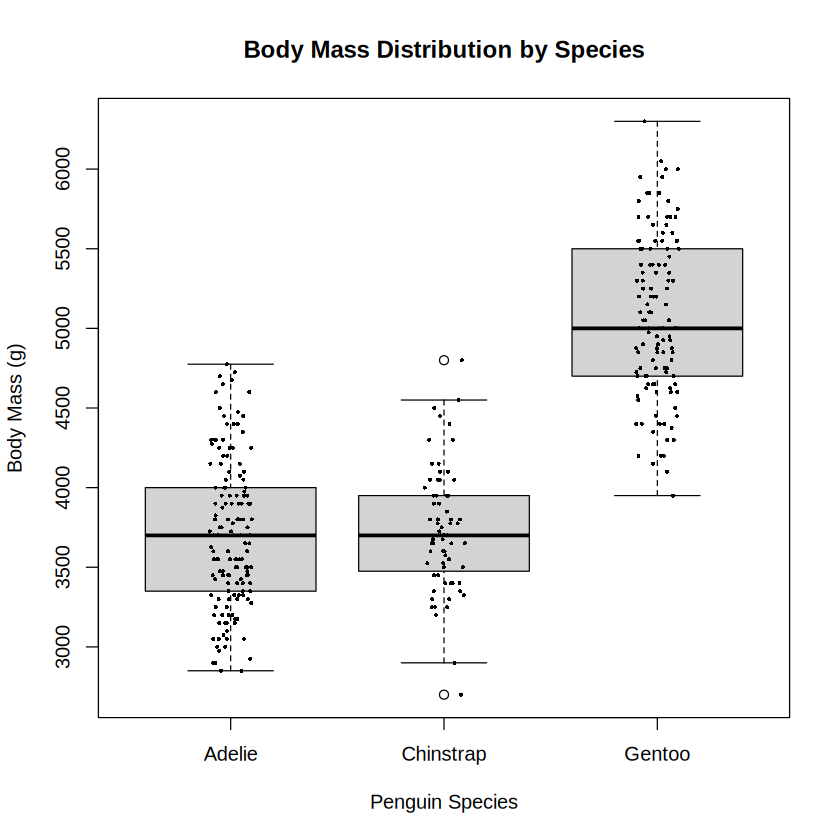

In [ ]:
# ============================================
# SPECIES-WISE BODY MASS BOXPLOT
# ============================================

boxplot(
  body_mass_g ~ species,
  data = body_mass_data,
  main = "Body Mass Distribution by Species",
  xlab = "Penguin Species",
  ylab = "Body Mass (g)",
  col = "lightgray"
)

stripchart(
  body_mass_g ~ species,
  data = body_mass_data,
  vertical = TRUE,
  method = "jitter",
  pch = 16,
  cex = 0.45,
  add = TRUE
)


### 7.3 Density Plot

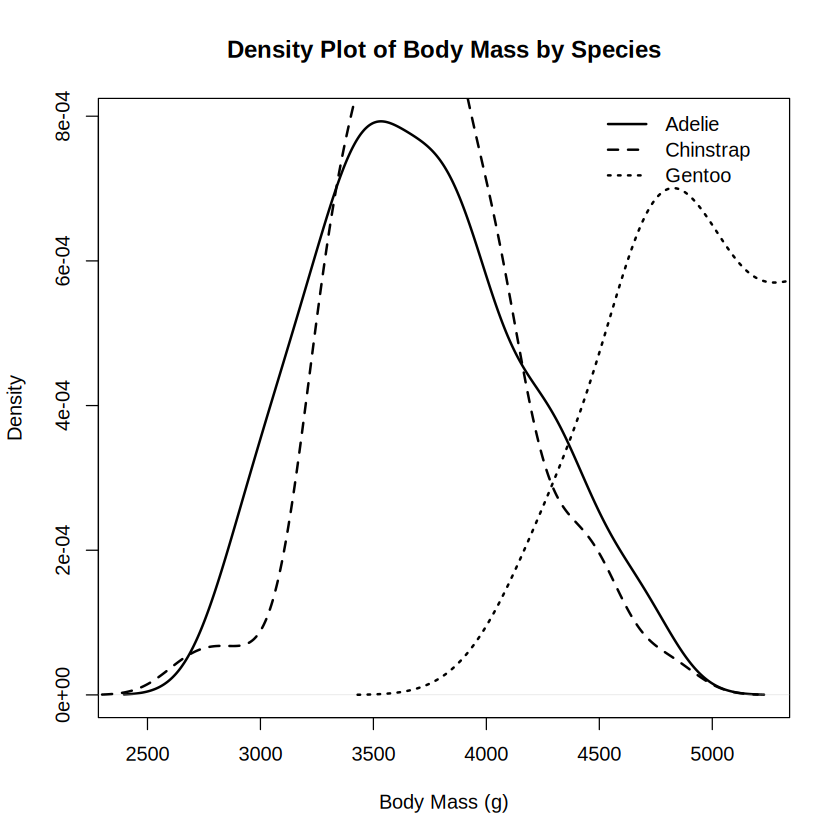

In [ ]:
# ============================================
# DENSITY PLOT BY SPECIES
# ============================================

species_levels <- levels(droplevels(body_mass_data$species))

first_density <- density(
  body_mass_data$body_mass_g[body_mass_data$species == species_levels[1]]
)

plot(
  first_density,
  main = "Density Plot of Body Mass by Species",
  xlab = "Body Mass (g)",
  ylab = "Density",
  lwd = 2
)

for (i in 2:length(species_levels)) {
  d <- density(
    body_mass_data$body_mass_g[body_mass_data$species == species_levels[i]]
  )
  lines(d, lwd = 2, lty = i)
}

legend(
  "topright",
  legend = species_levels,
  lty = seq_along(species_levels),
  lwd = 2,
  bty = "n"
)


## 8. Hypothesis Testing – Male vs Female Body Mass

### Hypotheses

**H0:** Male and female penguins have equal mean body mass.

**H1:** Male and female penguins have different mean body mass.

Significance level: **α = 0.05**.


## 9. Shapiro-Wilk Normality Tests by Sex

In [ ]:
# ============================================
# SHAPIRO-WILK TEST BY SEX
# ============================================

sex_levels <- levels(droplevels(body_mass_sex_data$sex))

shapiro_sex <- do.call(
  rbind,
  lapply(sex_levels, function(sx) {
    x <- body_mass_sex_data$body_mass_g[
      body_mass_sex_data$sex == sx
    ]
    test <- shapiro.test(x)
    data.frame(
      Sex = sx,
      N = length(x),
      W = unname(test$statistic),
      P_Value = test$p.value
    )
  })
)

print(shapiro_sex)

cat("\nInterpretation rule: p < 0.05 suggests evidence against normality.\n")


     Sex   N         W      P_Value
1 female 165 0.9193140 6.155316e-08
2   male 168 0.9250434 1.226814e-07

Interpretation rule: p < 0.05 suggests evidence against normality.


## 10. Q-Q Plots by Sex

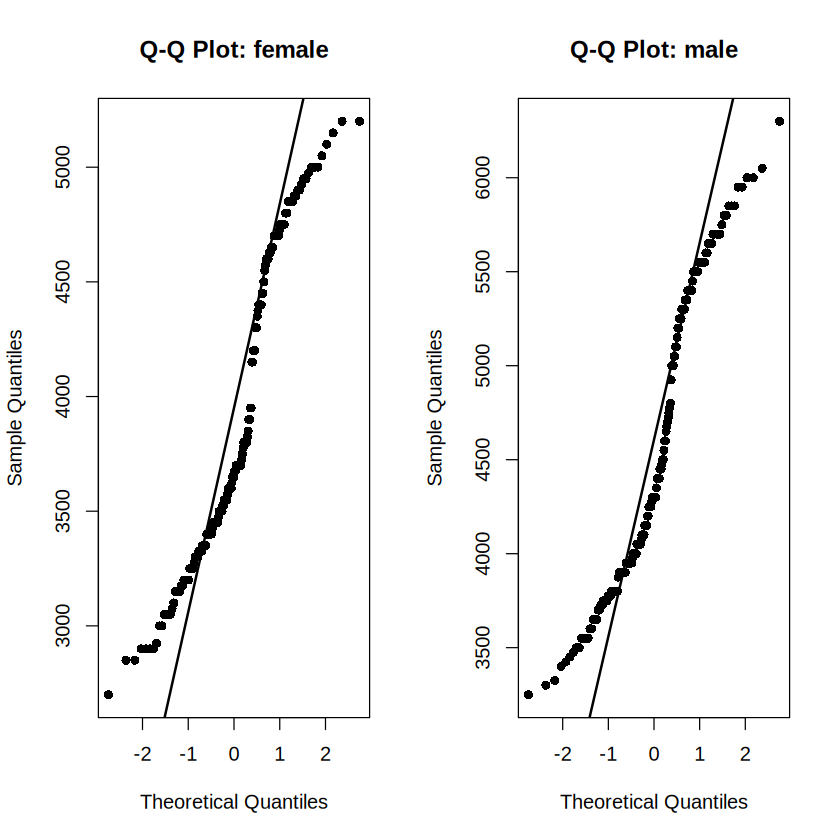

In [ ]:
# ============================================
# QQ PLOTS BY SEX
# ============================================

old_par <- par(no.readonly = TRUE)
par(mfrow = c(1, 2))

for (sx in sex_levels) {
  x <- body_mass_sex_data$body_mass_g[
    body_mass_sex_data$sex == sx
  ]
  qqnorm(
    x,
    main = paste("Q-Q Plot:", sx),
    pch = 16
  )
  qqline(x, lwd = 2)
}

par(old_par)


## 11. Independent Two-Sample Welch t-Test

Welch's t-test is used because it does not require equal population variances.


In [ ]:
# ============================================
# WELCH TWO-SAMPLE T-TEST
# ============================================

t_test_result <- t.test(
  body_mass_g ~ sex,
  data = body_mass_sex_data,
  var.equal = FALSE,
  conf.level = 0.95
)

print(t_test_result)

male_mean <- mean(
  body_mass_sex_data$body_mass_g[
    body_mass_sex_data$sex == "male"
  ]
)

female_mean <- mean(
  body_mass_sex_data$body_mass_g[
    body_mass_sex_data$sex == "female"
  ]
)

mean_difference <- male_mean - female_mean

cat("\nMale mean:", round(male_mean, 2), "g\n")
cat("Female mean:", round(female_mean, 2), "g\n")
cat("Male - Female mean difference:", round(mean_difference, 2), "g\n")

if (t_test_result$p.value < 0.05) {
  cat("\nConclusion: Reject H0. There is statistically significant evidence")
  cat(" of a difference in mean body mass between males and females.\n")
} else {
  cat("\nConclusion: Do not reject H0. There is insufficient evidence")
  cat(" of a difference in mean body mass between males and females.\n")
}



	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


Male mean: 4545.68 g
Female mean: 3862.27 g
Male - Female mean difference: 683.41 g

Conclusion: Reject H0. There is statistically significant evidence of a difference in mean body mass between males and females.


## 12. Cohen's d Effect Size

In [ ]:
# ============================================
# COHEN'S d
# ============================================

male <- body_mass_sex_data$body_mass_g[
  body_mass_sex_data$sex == "male"
]

female <- body_mass_sex_data$body_mass_g[
  body_mass_sex_data$sex == "female"
]

n_male <- length(male)
n_female <- length(female)

pooled_sd <- sqrt(
  ((n_male - 1) * var(male) +
   (n_female - 1) * var(female)) /
  (n_male + n_female - 2)
)

cohens_d <- (mean(male) - mean(female)) / pooled_sd

effect_magnitude <- if (abs(cohens_d) < 0.2) {
  "negligible"
} else if (abs(cohens_d) < 0.5) {
  "small"
} else if (abs(cohens_d) < 0.8) {
  "medium"
} else {
  "large"
}

cat("Cohen's d:", round(cohens_d, 3), "\n")
cat("Effect-size interpretation:", effect_magnitude, "\n")


Cohen's d: 0.936 
Effect-size interpretation: large 


## 13. 95% Confidence Interval for Difference in Means

The confidence interval below is the Welch t-test confidence interval for the mean difference, using R's group-order convention.


In [ ]:
# ============================================
# 95% CONFIDENCE INTERVAL
# ============================================

ci <- t_test_result$conf.int

cat(
  "95% Confidence Interval for the mean difference:",
  round(ci[1], 2), "to", round(ci[2], 2), "g\n"
)

cat(
  "Estimated difference:",
  round(unname(t_test_result$estimate[1] - t_test_result$estimate[2]), 2),
  "g\n"
)


95% Confidence Interval for the mean difference: -840.58 to -526.25 g
Estimated difference: -683.41 g


## 14. Sex-wise Body Mass Boxplot

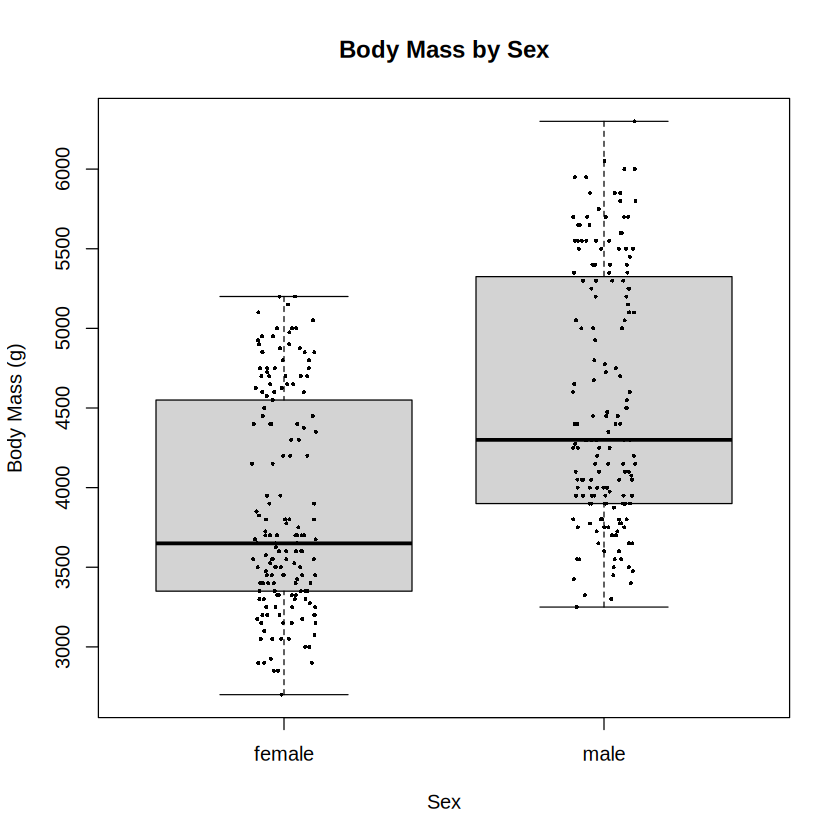

In [ ]:
# ============================================
# SEX-WISE BOXPLOT
# ============================================

boxplot(
  body_mass_g ~ sex,
  data = body_mass_sex_data,
  main = "Body Mass by Sex",
  xlab = "Sex",
  ylab = "Body Mass (g)",
  col = "lightgray"
)

stripchart(
  body_mass_g ~ sex,
  data = body_mass_sex_data,
  vertical = TRUE,
  method = "jitter",
  pch = 16,
  cex = 0.45,
  add = TRUE
)


## 15. One-Way ANOVA – Body Mass by Species

Model:

`body_mass_g ~ species`

Before interpreting ANOVA, the notebook checks normality and homogeneity of variance.


## 16. Shapiro-Wilk Normality Tests by Species

In [ ]:
# ============================================
# SHAPIRO-WILK BY SPECIES
# ============================================

shapiro_species <- do.call(
  rbind,
  lapply(species_levels, function(sp) {
    x <- body_mass_data$body_mass_g[
      body_mass_data$species == sp
    ]
    test <- shapiro.test(x)
    data.frame(
      Species = sp,
      N = length(x),
      W = unname(test$statistic),
      P_Value = test$p.value
    )
  })
)

print(shapiro_species)


    Species   N         W    P_Value
1    Adelie 151 0.9807079 0.03239702
2 Chinstrap  68 0.9844938 0.56050824
3    Gentoo 123 0.9859276 0.23361649


## 17. Species-wise Q-Q Plots

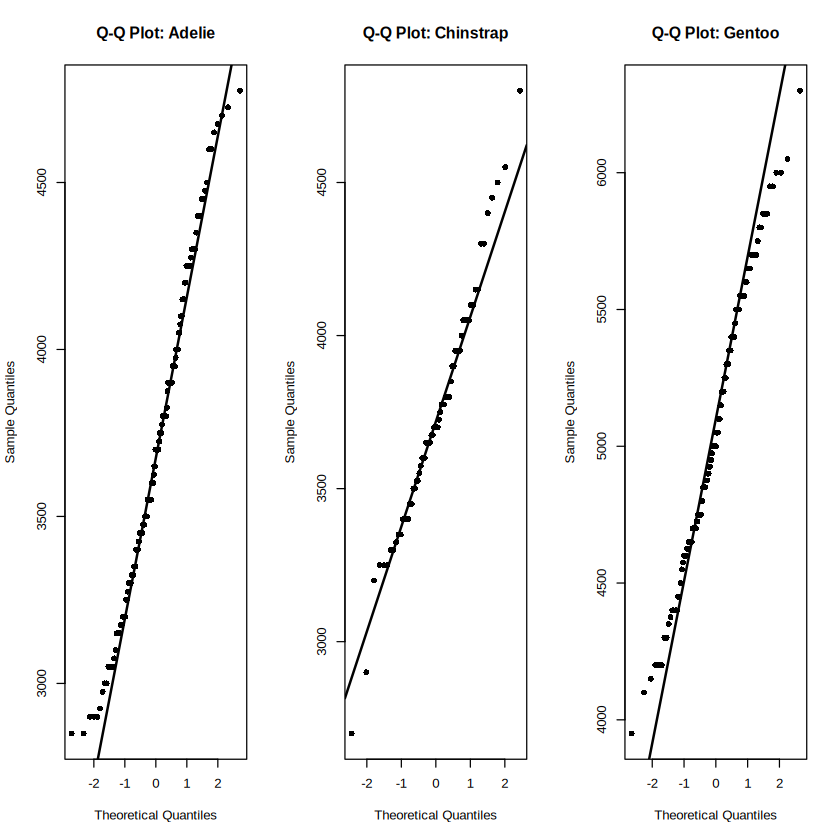

In [ ]:
# ============================================
# QQ PLOTS BY SPECIES
# ============================================

old_par <- par(no.readonly = TRUE)
par(mfrow = c(1, 3))

for (sp in species_levels) {
  x <- body_mass_data$body_mass_g[
    body_mass_data$species == sp
  ]
  qqnorm(
    x,
    main = paste("Q-Q Plot:", sp),
    pch = 16
  )
  qqline(x, lwd = 2)
}

par(old_par)


## 18. Levene's Test for Homogeneity of Variance

A median-centered Levene test is implemented directly in base R. This avoids the need for the `car` package.


In [ ]:
# ============================================
# BASE-R LEVENE'S TEST
# ============================================

levene_test_base <- function(y, group) {
  keep <- complete.cases(y, group)
  y <- y[keep]
  group <- droplevels(factor(group[keep]))

  group_medians <- tapply(y, group, median)
  deviations <- abs(y - group_medians[as.character(group)])

  levene_model <- aov(deviations ~ group)
  result <- summary(levene_model)[[1]]

  data.frame(
    F_Value = result[1, "F value"],
    df1 = result[1, "Df"],
    df2 = result[2, "Df"],
    P_Value = result[1, "Pr(>F)"]
  )
}

levene_body <- levene_test_base(
  body_mass_data$body_mass_g,
  body_mass_data$species
)

cat("Levene's test for body mass:\n")
print(levene_body)

if (levene_body$P_Value < 0.05) {
  cat("\nConclusion: Evidence suggests unequal variances across species.\n")
} else {
  cat("\nConclusion: There is insufficient evidence of unequal variances across species.\n")
}


Levene's test for body mass:
   F_Value df1 df2     P_Value
1 5.120251   2 339 0.006445083

Conclusion: Evidence suggests unequal variances across species.


## 19. One-Way ANOVA and Tukey HSD

In [ ]:
# ============================================
# ONE-WAY ANOVA
# ============================================

one_way_anova <- aov(
  body_mass_g ~ species,
  data = body_mass_data
)

anova_table <- summary(one_way_anova)[[1]]

cat("One-way ANOVA table:\n")
print(anova_table)

anova_F <- anova_table[1, "F value"]
anova_df1 <- anova_table[1, "Df"]
anova_df2 <- anova_table[2, "Df"]
anova_p <- anova_table[1, "Pr(>F)"]

cat("\nF-statistic:", round(anova_F, 3), "\n")
cat("Degrees of freedom:", anova_df1, "and", anova_df2, "\n")
cat("p-value:", format.pval(anova_p), "\n")

if (anova_p < 0.05) {
  cat("\nConclusion: Reject H0. Mean body mass differs significantly among species.\n")

  cat("\nTukey HSD post-hoc results:\n")
  tukey_body <- TukeyHSD(one_way_anova)
  print(tukey_body)
} else {
  cat("\nConclusion: Do not reject H0. There is insufficient evidence that mean body mass differs among species.\n")
}


One-way ANOVA table:
             Df    Sum Sq  Mean Sq F value    Pr(>F)    
species       2 146864214 73432107  343.63 < 2.2e-16 ***
Residuals   339  72443483   213698                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

F-statistic: 343.626 
Degrees of freedom: 2 and 339 
p-value: < 2.22e-16 

Conclusion: Reject H0. Mean body mass differs significantly among species.

Tukey HSD post-hoc results:
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = body_mass_data)

$species
                       diff       lwr       upr     p adj
Chinstrap-Adelie   32.42598 -126.5002  191.3522 0.8806666
Gentoo-Adelie    1375.35401 1243.1786 1507.5294 0.0000000
Gentoo-Chinstrap 1342.92802 1178.4810 1507.3750 0.0000000



## 20. Species Comparison Plot

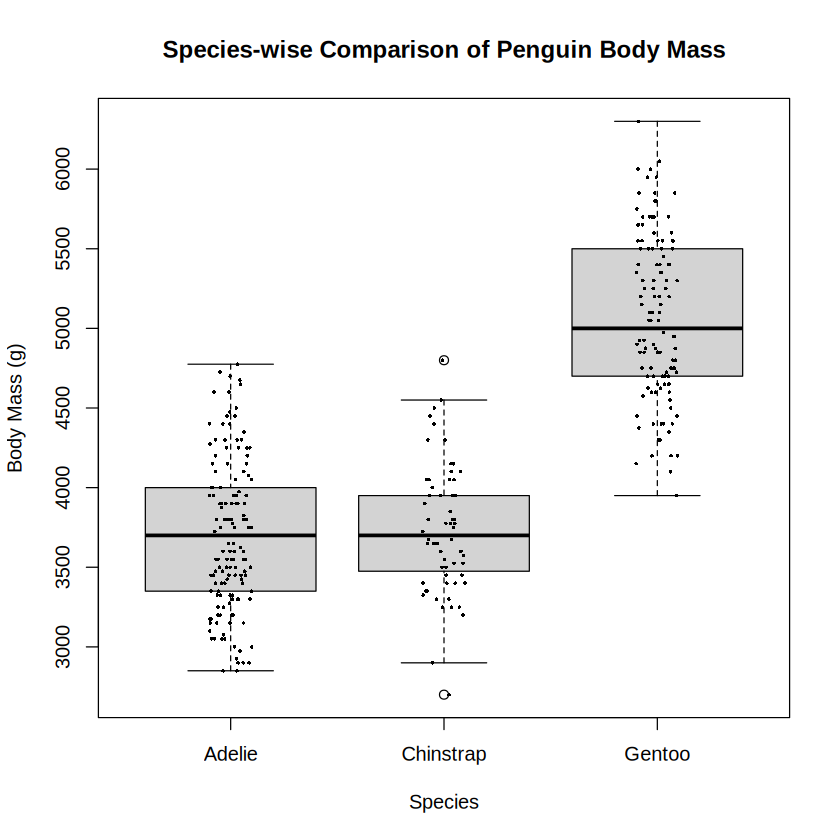

In [ ]:
# ============================================
# SPECIES COMPARISON PLOT
# ============================================

boxplot(
  body_mass_g ~ species,
  data = body_mass_data,
  main = "Species-wise Comparison of Penguin Body Mass",
  xlab = "Species",
  ylab = "Body Mass (g)",
  col = "lightgray"
)

stripchart(
  body_mass_g ~ species,
  data = body_mass_data,
  vertical = TRUE,
  method = "jitter",
  pch = 16,
  cex = 0.4,
  add = TRUE
)


## 21. Kruskal-Wallis Non-Parametric Test

The Kruskal-Wallis test is included as the non-parametric alternative. It is especially important if the ANOVA assumptions are substantially violated.

For completeness, it is also reported alongside ANOVA so the conclusions can be compared.


In [ ]:
# ============================================
# KRUSKAL-WALLIS TEST
# ============================================

kw_result <- kruskal.test(
  body_mass_g ~ species,
  data = body_mass_data
)

cat("Kruskal-Wallis test:\n")
print(kw_result)

cat("\nComparison with ANOVA:\n")

comparison_table <- data.frame(
  Method = c("One-way ANOVA", "Kruskal-Wallis"),
  Statistic = c(
    unname(anova_F),
    unname(kw_result$statistic)
  ),
  df = c(
    paste(anova_df1, anova_df2, sep = ", "),
    unname(kw_result$parameter)
  ),
  P_Value = c(
    anova_p,
    kw_result$p.value
  )
)

print(comparison_table)

if (levene_body$P_Value < 0.05) {
  cat("\nBecause Levene's test indicates unequal variances, the Kruskal-Wallis result is particularly relevant as a robustness check.\n")
} else {
  cat("\nLevene's test does not indicate substantial variance heterogeneity; ANOVA assumptions appear more reasonable.\n")
}

if (kw_result$p.value < 0.05) {
  cat("Kruskal-Wallis conclusion: species distributions differ significantly.\n")
} else {
  cat("Kruskal-Wallis conclusion: insufficient evidence of a difference among species distributions.\n")
}


Kruskal-Wallis test:

	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 217.6, df = 2, p-value < 2.2e-16


Comparison with ANOVA:
          Method Statistic     df      P_Value
1  One-way ANOVA  343.6263 2, 339 2.892368e-82
2 Kruskal-Wallis  217.5992      2 5.609512e-48

Because Levene's test indicates unequal variances, the Kruskal-Wallis result is particularly relevant as a robustness check.
Kruskal-Wallis conclusion: species distributions differ significantly.


## 22. Optional Non-Parametric Pairwise Comparisons

If Kruskal-Wallis is significant, pairwise Wilcoxon tests with Holm correction are used as a base-R post-hoc procedure.


In [ ]:
# ============================================
# PAIRWISE NON-PARAMETRIC POST-HOC TEST
# ============================================

if (kw_result$p.value < 0.05) {
  pairwise_kw <- pairwise.wilcox.test(
    body_mass_data$body_mass_g,
    body_mass_data$species,
    p.adjust.method = "holm",
    exact = FALSE
  )

  cat("Pairwise Wilcoxon tests with Holm correction:\n")
  print(pairwise_kw)
} else {
  cat("Kruskal-Wallis is not significant, so pairwise non-parametric post-hoc testing is not required.\n")
}


Pairwise Wilcoxon tests with Holm correction:

	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  body_mass_data$body_mass_g and body_mass_data$species 

          Adelie Chinstrap
Chinstrap 0.49   -        
Gentoo    <2e-16 <2e-16   

P value adjustment method: holm 


## 23. Two-Way ANOVA – Species, Sex and Interaction

Model:

`body_mass_g ~ species * sex`

This tests:
1. Main effect of species
2. Main effect of sex
3. Species × sex interaction


In [ ]:
# ============================================
# TWO-WAY ANOVA
# ============================================

two_way_anova <- aov(
  body_mass_g ~ species * sex,
  data = two_way_data
)

two_way_table <- anova(two_way_anova)

cat("Two-way ANOVA table:\n")
print(two_way_table)

cat("\nSpecies p-value:",
    format.pval(two_way_table["species", "Pr(>F)"]), "\n")

cat("Sex p-value:",
    format.pval(two_way_table["sex", "Pr(>F)"]), "\n")

cat("Species x Sex interaction p-value:",
    format.pval(two_way_table["species:sex", "Pr(>F)"]), "\n")

cat("\nInterpretation:\n")

if (two_way_table["species", "Pr(>F)"] < 0.05) {
  cat("- Species has a statistically significant effect on body mass.\n")
} else {
  cat("- Species does not have a statistically significant effect on body mass.\n")
}

if (two_way_table["sex", "Pr(>F)"] < 0.05) {
  cat("- Sex has a statistically significant effect on body mass.\n")
} else {
  cat("- Sex does not have a statistically significant effect on body mass.\n")
}

if (two_way_table["species:sex", "Pr(>F)"] < 0.05) {
  cat("- The species x sex interaction is statistically significant.\n")
} else {
  cat("- The species x sex interaction is not statistically significant.\n")
}


Two-way ANOVA table:
Analysis of Variance Table

Response: body_mass_g
             Df    Sum Sq  Mean Sq F value    Pr(>F)    
species       2 145190219 72595110 758.358 < 2.2e-16 ***
sex           1  37090262 37090262 387.460 < 2.2e-16 ***
species:sex   2   1676557   838278   8.757 0.0001973 ***
Residuals   327  31302628    95727                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Species p-value: < 2.22e-16 
Sex p-value: < 2.22e-16 
Species x Sex interaction p-value: 0.00019735 

Interpretation:
- Species has a statistically significant effect on body mass.
- Sex has a statistically significant effect on body mass.
- The species x sex interaction is statistically significant.


## 24. Two-Way ANOVA Diagnostic Plots

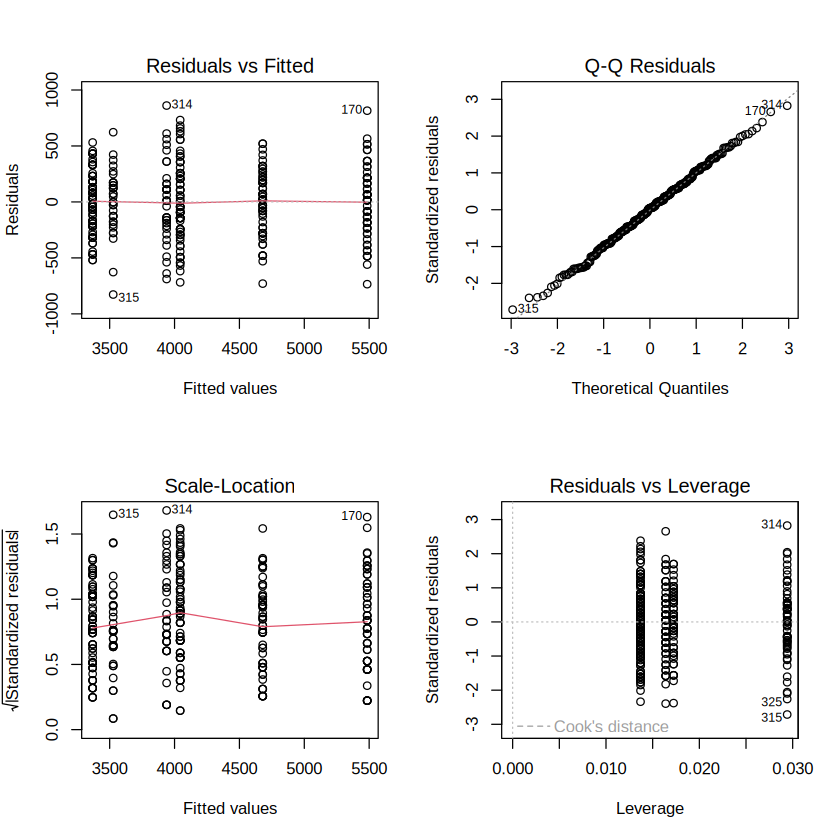

In [ ]:
# ============================================
# TWO-WAY ANOVA DIAGNOSTICS
# ============================================

old_par <- par(no.readonly = TRUE)
par(mfrow = c(2, 2))
plot(two_way_anova)
par(old_par)


## 25. Levene's Test for Two-Way ANOVA Groups

In [ ]:
# ============================================
# HOMOGENEITY CHECK FOR SPECIES x SEX GROUPS
# ============================================

two_way_group <- interaction(
  two_way_data$species,
  two_way_data$sex,
  drop = TRUE
)

levene_two_way <- levene_test_base(
  two_way_data$body_mass_g,
  two_way_group
)

cat("Levene's test across species x sex groups:\n")
print(levene_two_way)


Levene's test across species x sex groups:
   F_Value df1 df2   P_Value
1 1.390826   5 327 0.2272166


## 26. Two-Way ANOVA Interaction Plot

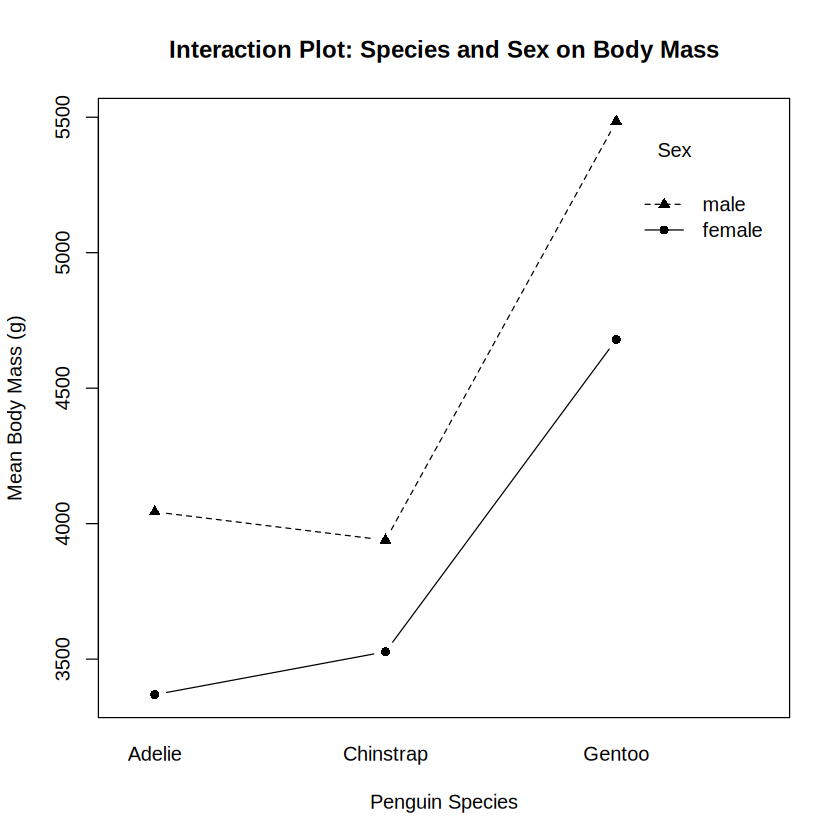

In [ ]:
# ============================================
# INTERACTION PLOT
# ============================================

interaction.plot(
  x.factor = two_way_data$species,
  trace.factor = two_way_data$sex,
  response = two_way_data$body_mass_g,
  fun = mean,
  type = "b",
  pch = c(16, 17),
  lty = c(1, 2),
  xlab = "Penguin Species",
  ylab = "Mean Body Mass (g)",
  trace.label = "Sex",
  main = "Interaction Plot: Species and Sex on Body Mass"
)


## 27. Additional Analysis – Flipper Length

The problem statement asks for an appropriate repeat of the analysis using `flipper_length_mm`.

Here we perform:
- Descriptive statistics by species
- Species-wise visualization
- Shapiro-Wilk tests
- Levene's test
- One-way ANOVA
- Tukey HSD when ANOVA is significant
- Kruskal-Wallis as a robustness/non-parametric alternative


In [ ]:
# ============================================
# FLIPPER LENGTH DESCRIPTIVE STATISTICS
# ============================================

flipper_species_stats <- do.call(
  rbind,
  lapply(species_levels, function(sp) {

    result <- descriptive_stats(
      flipper_data$flipper_length_mm[
        flipper_data$species == sp
      ]
    )

    result$Species <- sp
    result
  })
)

# Put Species as the first column
flipper_species_stats <- flipper_species_stats[, c(
  "Species",
  "N",
  "Mean",
  "Median",
  "Minimum",
  "Maximum",
  "Variance",
  "SD",
  "Q1",
  "Q3",
  "IQR",
  "Skewness",
  "Kurtosis"
)]

# Reset row names
rownames(flipper_species_stats) <- NULL

cat("Flipper-length descriptive statistics by species:\n")

# Round ONLY numeric columns
flipper_species_stats_rounded <- flipper_species_stats

numeric_columns <- sapply(
  flipper_species_stats_rounded,
  is.numeric
)

flipper_species_stats_rounded[numeric_columns] <- lapply(
  flipper_species_stats_rounded[numeric_columns],
  round,
  digits = 2
)

print(flipper_species_stats_rounded)

Flipper-length descriptive statistics by species:
    Species   N   Mean Median Minimum Maximum Variance   SD  Q1  Q3 IQR
1    Adelie 151 189.95    190     172     210    42.76 6.54 186 195   9
2 Chinstrap  68 195.82    196     178     212    50.86 7.13 191 201  10
3    Gentoo 123 217.19    216     203     231    42.05 6.48 212 221   9
  Skewness Kurtosis
1     0.09     3.28
2    -0.01     2.96
3     0.39     2.40


## 28. Flipper-Length Visualization

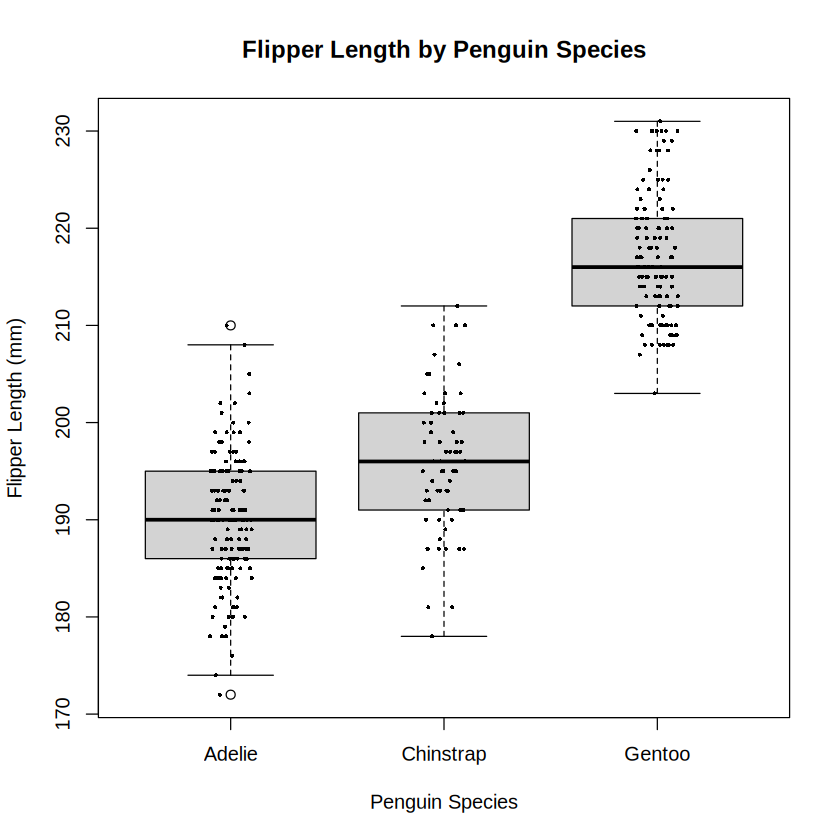

In [ ]:
# ============================================
# FLIPPER LENGTH BOXPLOT
# ============================================

boxplot(
  flipper_length_mm ~ species,
  data = flipper_data,
  main = "Flipper Length by Penguin Species",
  xlab = "Penguin Species",
  ylab = "Flipper Length (mm)",
  col = "lightgray"
)

stripchart(
  flipper_length_mm ~ species,
  data = flipper_data,
  vertical = TRUE,
  method = "jitter",
  pch = 16,
  cex = 0.45,
  add = TRUE
)


## 29. Flipper-Length Normality and Variance Checks

In [ ]:
# ============================================
# FLIPPER LENGTH ASSUMPTION CHECKS
# ============================================

shapiro_flipper <- do.call(
  rbind,
  lapply(species_levels, function(sp) {
    x <- flipper_data$flipper_length_mm[
      flipper_data$species == sp
    ]
    test <- shapiro.test(x)
    data.frame(
      Species = sp,
      N = length(x),
      W = unname(test$statistic),
      P_Value = test$p.value
    )
  })
)

cat("Shapiro-Wilk tests for flipper length:\n")
print(shapiro_flipper)

levene_flipper <- levene_test_base(
  flipper_data$flipper_length_mm,
  flipper_data$species
)

cat("\nLevene's test for flipper length:\n")
print(levene_flipper)


Shapiro-Wilk tests for flipper length:
    Species   N         W     P_Value
1    Adelie 151 0.9933916 0.720046617
2 Chinstrap  68 0.9889115 0.810644659
3    Gentoo 123 0.9621936 0.001619814

Levene's test for flipper length:
    F_Value df1 df2   P_Value
1 0.3305621   2 339 0.7187511


## 30. Flipper-Length One-Way ANOVA and Kruskal-Wallis

In [ ]:
# ============================================
# FLIPPER LENGTH ANOVA
# ============================================

flipper_anova <- aov(
  flipper_length_mm ~ species,
  data = flipper_data
)

flipper_anova_table <- summary(flipper_anova)[[1]]

cat("Flipper-length one-way ANOVA:\n")
print(flipper_anova_table)

flipper_F <- flipper_anova_table[1, "F value"]
flipper_df1 <- flipper_anova_table[1, "Df"]
flipper_df2 <- flipper_anova_table[2, "Df"]
flipper_p <- flipper_anova_table[1, "Pr(>F)"]

cat("\nF-statistic:", round(flipper_F, 3), "\n")
cat("p-value:", format.pval(flipper_p), "\n")

if (flipper_p < 0.05) {
  cat("\nANOVA is significant. Tukey HSD results:\n")
  print(TukeyHSD(flipper_anova))
} else {
  cat("\nANOVA is not significant; Tukey HSD is not required.\n")
}

flipper_kw <- kruskal.test(
  flipper_length_mm ~ species,
  data = flipper_data
)

cat("\nFlipper-length Kruskal-Wallis test:\n")
print(flipper_kw)

cat("\nConclusion:\n")
if (flipper_p < 0.05) {
  cat("There is statistically significant evidence that mean flipper length differs among species.\n")
} else {
  cat("There is insufficient evidence that mean flipper length differs among species.\n")
}


Flipper-length one-way ANOVA:
             Df Sum Sq Mean Sq F value    Pr(>F)    
species       2  52473 26236.6   594.8 < 2.2e-16 ***
Residuals   339  14953    44.1                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

F-statistic: 594.802 
p-value: < 2.22e-16 

ANOVA is significant. Tukey HSD results:
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = flipper_data)

$species
                      diff       lwr       upr p adj
Chinstrap-Adelie  5.869887  3.586583  8.153191     0
Gentoo-Adelie    27.233349 25.334376 29.132323     0
Gentoo-Chinstrap 21.363462 19.000841 23.726084     0


Flipper-length Kruskal-Wallis test:

	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 244.89, df = 2, p-value < 2.2e-16


Conclusion:
There is statistically significant evidence that mean flipper length differs among species.


## 31. Final Results Summary

This section creates compact summary tables from the actual R results. No results are hard-coded.


In [ ]:
# ============================================
# FINAL SUMMARY TABLES
# ============================================

sex_summary <- data.frame(
  Test = "Welch Two-Sample t-Test",
  Statistic = unname(t_test_result$statistic),
  df = unname(t_test_result$parameter),
  P_Value = t_test_result$p.value,
  Mean_Difference = mean_difference,
  CI_Lower = ci[1],
  CI_Upper = ci[2],
  Cohens_d = cohens_d
)

species_summary <- data.frame(
  Test = c("One-way ANOVA", "Kruskal-Wallis"),
  Statistic = c(anova_F, unname(kw_result$statistic)),
  df = c(anova_df1, unname(kw_result$parameter)),
  P_Value = c(anova_p, kw_result$p.value)
)

two_way_summary <- data.frame(
  Effect = c("Species", "Sex", "Species x Sex"),
  P_Value = c(
    two_way_table["species", "Pr(>F)"],
    two_way_table["sex", "Pr(>F)"],
    two_way_table["species:sex", "Pr(>F)"]
  )
)

flipper_summary <- data.frame(
  Test = c("One-way ANOVA", "Kruskal-Wallis"),
  Statistic = c(flipper_F, unname(flipper_kw$statistic)),
  df = c(flipper_df1, unname(flipper_kw$parameter)),
  P_Value = c(flipper_p, flipper_kw$p.value)
)

cat("Male vs Female summary:\n")
print(round(sex_summary, 4))

cat("\nSpecies body-mass summary:\n")
print(round(species_summary, 4))

cat("\nTwo-way ANOVA summary:\n")
print(round(two_way_summary, 4))

cat("\nFlipper-length summary:\n")
print(round(flipper_summary, 4))


Male vs Female summary:


ERROR: Error in Math.data.frame(structure(list(Test = "Welch Two-Sample t-Test", : non-numeric-alike variable(s) in data frame: Test


## 32. Final Statistical Conclusions

The following statements are generated from the actual test results rather than being assumed in advance.


In [ ]:
# ============================================
# AUTOMATIC FINAL CONCLUSIONS
# ============================================

cat("============================================\n")
cat("FINAL STATISTICAL CONCLUSIONS\n")
cat("============================================\n\n")

# Sex conclusion
if (t_test_result$p.value < 0.05) {
  cat("1. Sex and body mass: There is statistically significant evidence of a difference in mean body mass between male and female penguins.\n")
} else {
  cat("1. Sex and body mass: There is insufficient evidence of a difference in mean body mass between male and female penguins.\n")
}

cat(
  "   Cohen's d = ", round(cohens_d, 3),
  " (", effect_magnitude, " effect).\n",
  sep = ""
)

# Species conclusion
if (anova_p < 0.05) {
  cat("2. Species and body mass: One-way ANOVA indicates a statistically significant difference in mean body mass among species.\n")
} else {
  cat("2. Species and body mass: One-way ANOVA does not provide sufficient evidence of different mean body masses among species.\n")
}

# Non-parametric conclusion
if (kw_result$p.value < 0.05) {
  cat("3. Kruskal-Wallis: The non-parametric test also indicates significant differences among species.\n")
} else {
  cat("3. Kruskal-Wallis: The non-parametric test does not indicate significant differences among species.\n")
}

# Two-way conclusion
if (two_way_table["species", "Pr(>F)"] < 0.05) {
  cat("4. Two-way ANOVA: Species has a significant effect on body mass.\n")
} else {
  cat("4. Two-way ANOVA: Species does not have a significant effect on body mass.\n")
}

if (two_way_table["sex", "Pr(>F)"] < 0.05) {
  cat("5. Two-way ANOVA: Sex has a significant effect on body mass.\n")
} else {
  cat("5. Two-way ANOVA: Sex does not have a significant effect on body mass.\n")
}

if (two_way_table["species:sex", "Pr(>F)"] < 0.05) {
  cat("6. Interaction: The species x sex interaction is statistically significant, indicating that the sex-related difference is not the same across species.\n")
} else {
  cat("6. Interaction: The species x sex interaction is not statistically significant.\n")
}

# Flipper conclusion
if (flipper_p < 0.05) {
  cat("7. Flipper length: There is statistically significant evidence that mean flipper length differs among species.\n")
} else {
  cat("7. Flipper length: There is insufficient evidence that mean flipper length differs among species.\n")
}

cat("\nAll conclusions above are based on alpha = 0.05 and the observations in the downloaded Palmer Penguins dataset.\n")


FINAL STATISTICAL CONCLUSIONS

1. Sex and body mass: There is statistically significant evidence of a difference in mean body mass between male and female penguins.
   Cohen's d = 0.936 (large effect).
2. Species and body mass: One-way ANOVA indicates a statistically significant difference in mean body mass among species.
3. Kruskal-Wallis: The non-parametric test also indicates significant differences among species.
4. Two-way ANOVA: Species has a significant effect on body mass.
5. Two-way ANOVA: Sex has a significant effect on body mass.
6. Interaction: The species x sex interaction is statistically significant, indicating that the sex-related difference is not the same across species.
7. Flipper length: There is statistically significant evidence that mean flipper length differs among species.

All conclusions above are based on alpha = 0.05 and the observations in the downloaded Palmer Penguins dataset.


## 33. Submission Checklist

The notebook now includes all major requirements from the laboratory problem statement:

- Dataset downloaded automatically
- Dataset inspection and preprocessing
- Missing-value analysis
- Overall descriptive statistics
- Species-wise descriptive statistics
- Mean, median, minimum, maximum
- Variance and standard deviation
- Q1, Q3 and IQR
- Skewness and kurtosis
- Histogram
- Species-wise boxplot
- Density plot
- Male/female hypothesis testing
- Shapiro-Wilk tests
- Q-Q plots
- Independent two-sample Welch t-test
- 95% confidence interval
- Cohen's d
- Sex-wise boxplot
- One-way ANOVA
- Levene's test
- Tukey HSD
- Kruskal-Wallis test
- ANOVA vs Kruskal-Wallis comparison
- Two-way ANOVA
- Species effect
- Sex effect
- Species × sex interaction
- Two-way ANOVA diagnostic plots
- Interaction plot
- Flipper-length analysis
- Flipper-length ANOVA/Tukey/Kruskal-Wallis
- Final automatically generated statistical conclusions

### Important
Run the notebook from **top to bottom** in a Google Colab **R runtime**. The notebook does not require `car`, `rstatix`, `effectsize`, `tidyverse`, `knitr`, or `kableExtra`, which removes the dependency problem encountered in the original notebook.
